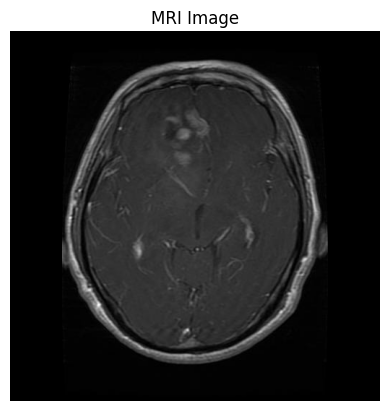

In [17]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

img = mpimg.imread("/Te-gl_5.jpg")

plt.imshow(img, cmap='gray')
plt.title("MRI Image")
plt.axis('off')
plt.show()

In [19]:
import numpy as np

# If image has 3 channels, convert to grayscale
if len(img.shape) == 3:
    img_gray = np.mean(img, axis=2)
else:
    img_gray = img

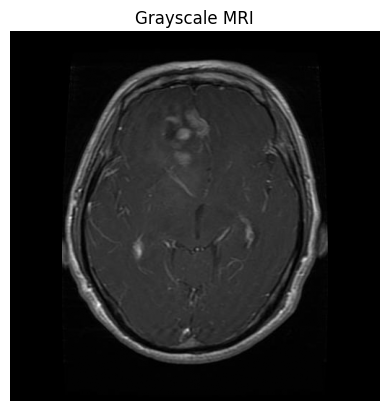

In [20]:
import matplotlib.pyplot as plt

plt.imshow(img_gray, cmap='gray')
plt.title("Grayscale MRI")
plt.axis('off')
plt.show()

In [21]:
roi = img_gray[80:180, 80:180]   # adjust if needed

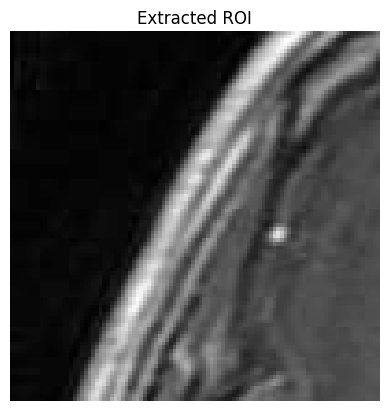

In [22]:
plt.imshow(roi, cmap='gray')
plt.title("Extracted ROI")
plt.axis('off')
plt.show()

In [23]:
import numpy as np

# Create PET-like signal
pet_like = roi * 0.6 + np.random.normal(0, 0.05, roi.shape)

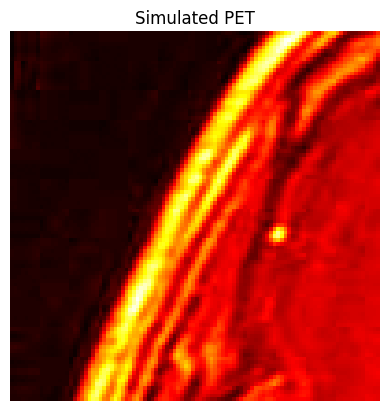

In [24]:
import matplotlib.pyplot as plt

plt.imshow(pet_like, cmap='hot')
plt.title("Simulated PET")
plt.axis('off')
plt.show()

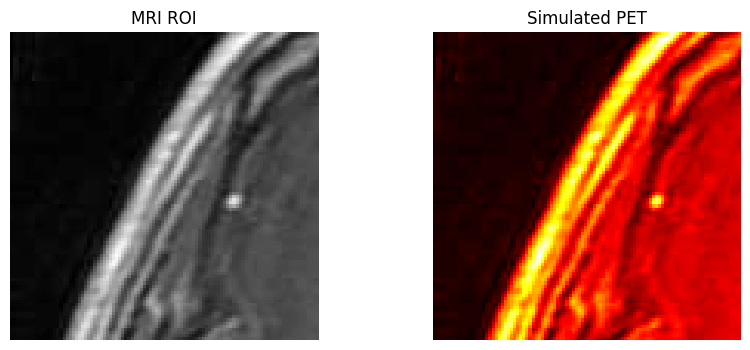

In [25]:
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.imshow(roi, cmap='gray')
plt.title("MRI ROI")
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(pet_like, cmap='hot')
plt.title("Simulated PET")
plt.axis('off')

plt.show()

In [26]:
X = roi.flatten().reshape(-1, 1)   # MRI values
y = pet_like.flatten()             # PET values

In [27]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [28]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor()
model.fit(X_train, y_train)

RandomForestRegressor()

In [29]:
y_pred = model.predict(X_test)

In [30]:
from sklearn.metrics import r2_score

print("R2 Score:", r2_score(y_test, y_pred))

R2 Score: 0.9999941259215764


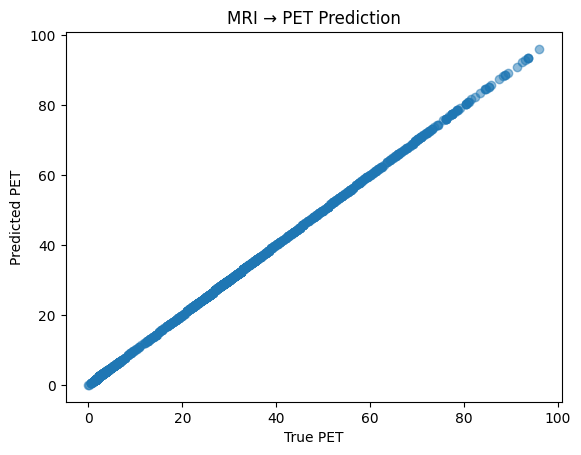

In [31]:
import matplotlib.pyplot as plt

plt.scatter(y_test, y_pred, alpha=0.5)
plt.xlabel("True PET")
plt.ylabel("Predicted PET")
plt.title("MRI → PET Prediction")
plt.show()